## Preprocessing 3
###  threshold channel saturation (penyakit masih ada) - median - gradien morp - / threshold channel hijau (penyakit hilang) - median - masking - grayscale - menggabungkan gradien morp dengan grayscale

In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

Kode di atas digunakan untuk mengimpor seluruh library yang dibutuhkan dalam praktikum pengolahan citra digital dan klasifikasi penyakit daun tomat. Library `os` digunakan untuk mengakses sistem file, seperti membaca daftar folder dan nama file gambar pada dataset. `cv2` dari OpenCV digunakan untuk membaca citra dari file dan mengkonversi ruang warna, seperti BGR ke grayscale, RGB, maupun HSV. `matplotlib.pyplot` digunakan untuk menampilkan hasil citra pada setiap tahapan proses pengolahan, serta untuk menampilkan visualisasi seperti heatmap korelasi fitur dan confusion matrix. `numpy` digunakan untuk operasi array dan perhitungan matriks, seperti pembuatan kernel, padding citra, dan manipulasi nilai piksel secara manual. `pandas` digunakan untuk menyusun hasil ekstraksi fitur ke dalam bentuk tabel (DataFrame), kemudian menyimpannya ke dan membacanya kembali dari file CSV.

Selanjutnya, dari `sklearn.model_selection` diimpor `train_test_split` yang digunakan untuk membagi data menjadi data latih (training) dan data uji (testing). Dari `sklearn.metrics` diimpor berbagai fungsi evaluasi seperti `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `classification_report`, `confusion_matrix`, dan `ConfusionMatrixDisplay` yang digunakan untuk mengukur dan menampilkan performa model klasifikasi. Dari `skimage.feature` diimpor `graycomatrix` dan `graycoprops` yang merupakan inti dari proses ekstraksi fitur tekstur menggunakan metode GLCM (Gray-Level Co-occurrence Matrix). Sementara `entropy` dari `scipy.stats` digunakan untuk menghitung nilai entropi sebagai salah satu fitur tekstur tambahan dari matriks GLCM.

Terakhir, diimpor tiga algoritma klasifikasi yang akan digunakan dan dibandingkan performanya, yaitu `RandomForestClassifier` dari `sklearn.ensemble`, `SVC` (Support Vector Classifier) dari `sklearn.svm`, dan `KNeighborsClassifier` dari `sklearn.neighbors`. Sedangkan `seaborn` digunakan untuk membuat visualisasi statistik yang lebih informatif, terutama untuk menampilkan heatmap korelasi antar fitur hasil ekstraksi.

In [2]:
data = []
labels = []
file_name = []

path_dataset = "archive/tomato/train/"

target_classes = [
    "Tomato___Early_blight", 
    "Tomato___Septoria_leaf_spot", 
    "Tomato___healthy"
]

for sub_folder in target_classes:
    path_sub_folder = os.path.join(path_dataset, sub_folder)
    
    sub_folder_files = os.listdir(path_sub_folder)
    
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join(path_sub_folder, filename)
        img = cv.imread(img_path)
        
        if img is not None:
            img = img.astype(np.uint8)
            
            data.append(img)
            labels.append(sub_folder)
            file_name.append(filename)
            
data = np.array(data, dtype=object)
labels = np.array(labels)


Kode di atas digunakan untuk memuat (load) seluruh data citra daun tomat dari dataset ke dalam memori, sekaligus memberi label pada masing-masing citra sesuai kelasnya. Tiga buah list disiapkan di awal, yaitu `data` untuk menampung array citra, `labels` untuk menampung nama kelas dari setiap citra, dan `file_name` untuk menampung nama file aslinya. Variabel `path_dataset` menunjuk ke folder utama tempat data latih disimpan, sedangkan `target_classes` berisi tiga nama folder kelas yang akan diproses, yaitu `Tomato___Early_blight`, `Tomato___Septoria_leaf_spot`, dan `Tomato___healthy`.

Selanjutnya, dilakukan perulangan (loop) terhadap setiap nama kelas pada `target_classes`. Untuk setiap kelas, path lengkap ke sub-foldernya dibentuk menggunakan `os.path.join`, kemudian seluruh nama file di dalam sub-folder tersebut diambil dengan `os.listdir`. Loop kedua (`enumerate`) dilakukan terhadap setiap file dalam sub-folder tersebut, di mana setiap file dibaca menggunakan `cv.imread` dari OpenCV sehingga citra dimuat dalam format BGR.

Setiap citra yang berhasil dibaca (`img is not None`) akan dipastikan tipe datanya berupa `uint8` menggunakan `astype`, lalu dimasukkan ke dalam list `data`. Bersamaan dengan itu, nama kelas (`sub_folder`) dimasukkan ke list `labels`, dan nama filenya dimasukkan ke list `file_name`. Pengecekan `if img is not None` ini penting untuk menghindari error pada proses berikutnya, seandainya ada file yang corrupt atau gagal dibaca oleh OpenCV.

Setelah seluruh citra dari ketiga kelas selesai dimuat, list `data` dan `labels` dikonversi menjadi `numpy array`. Variabel `data` dikonversi dengan parameter `dtype=object`, bukan tipe numerik biasa, karena setiap citra dalam dataset kemungkinan memiliki ukuran (dimensi) yang berbeda-beda, sehingga tidak bisa digabungkan langsung menjadi satu array numpy multidimensi yang seragam. Dengan `dtype=object`, setiap elemen array tetap berupa array citra individual yang independen, layaknya sebuah list biasa namun dibungkus dalam struktur numpy array.

In [3]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img, dtype=np.float32)
    height, width = img.shape
    
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
            
    return canvas
 
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
], dtype=np.float32)

kernelSharpening = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=np.float32)

def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    canvas = np.zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)

def gabung_tepi(*edges):
    gabungan = np.zeros_like(edges[0], dtype=np.float32)
    for e in edges:
        gabungan += e.astype(np.float32)
    gabungan = gabungan * 255.0 / np.max(gabungan)
    return np.clip(gabungan, 0, 255).astype(np.uint8)

sobelx = np.array([[-1, 0, 1], 
                   [-2, 0, 2], 
                   [-1, 0, 1]],dtype=np.float32)
sobely = np.array([[1, 2, 1],
                   [0, 0, 0],
                   [-1, -2, -1]], dtype=np.float32)

prewittx = np.array([[-1, 0, 1],
                      [-1, 0, 1], 
                      [-1, 0, 1]], dtype=np.float32)
prewitty = np.array([[1, 1, 1], 
                      [0, 0, 0], 
                      [-1, -1, -1]], dtype=np.float32)

robertsx = np.array([[1, 0], 
                     [0, -1]], dtype=np.float32)
robertsy = np.array([[0, 1], 
                     [-1, 0]], dtype=np.float32)

Kode di atas mendefinisikan sekumpulan fungsi dan kernel yang digunakan untuk operasi konvolusi, smoothing/sharpening, serta deteksi tepi pada citra. Fungsi `convolution` digunakan untuk melakukan operasi konvolusi secara manual pada citra. Fungsi ini menerima `img` (citra) dan `kernel` (matriks kernel), menghitung `pad_size` dari setengah ukuran kernel, lalu melakukan padding pada citra menggunakan `np.pad` dengan mode `'constant'` (nilai padding berupa 0). Hasil konvolusi ditampung pada `canvas` bertipe `float32`. Untuk setiap piksel, diambil region sebesar kernel dari citra yang sudah di-padding, dikalikan elemen-per-elemen dengan kernel, lalu dijumlahkan seluruh hasilnya menggunakan `np.sum(region * kernel)`.

Dua kernel didefinisikan setelahnya. `kernelSmoothing` berukuran 3x3 dengan total bobot 1, berfungsi meratakan/menghaluskan citra dengan memberi bobot lebih besar pada piksel tengah (1/5) dibanding piksel tetangga (1/10). `kernelSharpening` menggunakan pola klasik penajaman gambar dengan nilai 5 di tengah dan -1 di empat sisi, berfungsi mempertegas detail/tepi pada citra.

Fungsi `edge` digunakan untuk menghitung magnitude tepi dari citra menggunakan sepasang kernel arah horizontal (`kernelx`) dan vertikal (`kernely`). Citra dikonvolusi dengan kedua kernel untuk mendapatkan gradien `gx` dan `gy`, lalu magnitude tepi dihitung dengan menjumlahkan nilai absolut keduanya (`np.abs(gx) + np.abs(gy)`), bukan menggunakan rumus akar kuadrat (`sqrt(gx² + gy²)`). Hasilnya dinormalisasi ke rentang 0-255 dengan dikalikan 255 lalu dibagi nilai maksimumnya, kemudian di-clip sebelum dikonversi ke tipe data `uint8`.

Fungsi `gabung_tepi` digunakan untuk menggabungkan beberapa hasil deteksi tepi (dari operator berbeda) menjadi satu citra tepi gabungan, dengan menerima sejumlah argumen variabel (`*edges`), menjumlahkan seluruhnya ke dalam `gabungan` bertipe `float32`, lalu menormalisasi dan clip hasilnya dengan cara yang sama seperti pada fungsi `edge`.

Bagian terakhir mendefinisikan tiga pasang kernel operator deteksi tepi klasik. **Sobel** (`sobelx`, `sobely`) berukuran 3x3, memberikan bobot lebih besar (2) pada piksel yang berada tepat di tengah baris/kolom arah gradiennya, sehingga deteksi tepinya cenderung lebih halus. **Prewitt** (`prewittx`, `prewitty`) juga berukuran 3x3, namun dengan bobot yang seragam (1) pada seluruh piksel di arah gradiennya, sehingga perhitungannya lebih sederhana. **Roberts** (`robertsx`, `robertsy`) berukuran lebih kecil (2x2), hanya menghitung perbedaan antar piksel yang berdekatan secara diagonal, sehingga lebih sensitif terhadap perubahan intensitas kecil namun juga lebih rentan terhadap noise karena area perhitungannya yang sangat kecil.

In [4]:
def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)
    
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    canvas[i, j] = np.sum(region) // area
                    
        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    region_flat = np.sort(region.ravel())
                    canvas[i, j] = region_flat[(size * size) // 2]
                    
        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                            
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                            
                    canvas[i, j] = mode_val
                    
    return canvas

Kode di atas mendefinisikan sebuah fungsi `filter` yang bisa melakukan tiga jenis filtering berbeda (mean, median, dan modus) dalam satu fungsi yang sama, dengan parameter `mode` sebagai penentu jenis filter yang dipilih. Fungsi ini menerima tiga parameter, yaitu `img` (citra yang akan difilter), `size` (ukuran kernel/jendela filter), dan `mode` (jenis filter yang ingin digunakan, berupa string `'mean'`, `'median'`, atau `'modus'`). Citra di-padding menggunakan `np.pad` dengan mode `'edge'` agar ukuran citra hasil tetap sama dengan citra asli, dengan `pad` dihitung dari setengah ukuran kernel.

Pemilihan jenis filter dilakukan menggunakan struktur `match...case`, yaitu fitur pattern matching yang baru tersedia sejak Python 3.10, sebagai alternatif yang lebih ringkas dibandingkan rangkaian `if...elif...else`.

Pada `case 'mean'`, dihitung dulu luas area kernel (`area = size * size`), kemudian untuk setiap piksel diambil region dari citra yang sudah di-padding, lalu dijumlahkan seluruh nilainya dengan `np.sum(region)` dan dibagi dengan luas area menggunakan pembagian bulat (`//`), sehingga menghasilkan nilai rata-rata (mean) dari region tersebut yang dibulatkan ke bawah.

Pada `case 'median'`, region diratakan menjadi array 1 dimensi, diurutkan dengan `np.sort`, lalu diambil nilai tengahnya sebagai hasil median.

Pada `case 'modus'`, dilakukan pendekatan yang lebih manual dan kompleks. Untuk setiap region, nilai-nilainya diratakan menjadi array 1 dimensi (`values`), kemudian dihitung frekuensi kemunculan setiap nilai menggunakan dictionary `count`, di mana setiap nilai piksel dijadikan key dan jumlah kemunculannya dijadikan value. Setelah seluruh nilai dihitung frekuensinya, dilakukan pencarian nilai dengan frekuensi tertinggi (`max_count`) melalui perulangan terhadap seluruh item pada dictionary `count`, dan nilai dengan frekuensi tertinggi tersebut (`mode_val`) disimpan sebagai hasil modus pada posisi piksel yang bersangkutan.

Setelah seluruh piksel diproses sesuai mode yang dipilih, fungsi mengembalikan `canvas` sebagai citra hasil filtering. Perlu dicatat bahwa implementasi filter modus dengan dictionary murni Python akan berjalan jauh lebih lambat dibandingkan dua mode lainnya, terutama jika diterapkan pada citra berukuran besar atau jumlah data yang banyak, karena operasinya tidak vectorized dan dilakukan murni dengan loop Python.

In [5]:
def dilasi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width), dtype=np.uint8)
    
    for i in range(center, height - center):
        for j in range(center, width - center):
            if image[i, j] == 255:
                for k in range(k_height):
                    for l in range(k_width):
                        if kernel[k, l] == 1:
                            hasil[i + k - center, j + l - center] = 255
    return hasil

def erosi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width), dtype=np.uint8)
    
    for i in range(center, height - center):
        for j in range(center, width - center):
            cocok = True
            for k in range(k_height):
                for l in range(k_width):
                    if kernel[k, l] == 1 and image[i + k - center, j + l - center] == 0:
                        cocok = False
                        break
                if not cocok:
                    break
            if cocok:
                hasil[i, j] = 255
    return hasil

def gradient_morph(image, kernel):
    hasil_dilasi = dilasi(image, kernel)
    hasil_erosi = erosi(image, kernel)
    hasil_gradient = np.clip(hasil_dilasi.astype(np.int16) - hasil_erosi.astype(np.int16), 0, 255).astype(np.uint8)
    return hasil_gradient
data_p3 = []

kernel_3x3 = np.ones((3,3), dtype=np.uint8)

for idx in range(len(data)):
    img_bgr = data[idx].astype(np.uint8)

    img_hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)
    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

    tinggi, lebar = img_rgb.shape[:2]

    # =========================
    # TAHAP A: OUTLINE HSV
    # =========================
    mask_utuh = np.zeros((tinggi, lebar), dtype=np.uint8)

    for x in range(tinggi):
        for y in range(lebar):
            sat = img_hsv[x, y, 1]
            mask_utuh[x, y] = 255 if sat > 35 else 0

    mask_utuh_clean = filter(mask_utuh, 5, 'median')
    hasil_gradient = gradient_morph(mask_utuh_clean, kernel_3x3)

    # =========================
    # TAHAP B: REMOVE DISEASE
    # =========================
    mask_hapus_penyakit = np.zeros((tinggi, lebar), dtype=np.uint8)

    for x in range(tinggi):
        for y in range(lebar):
            r = int(img_rgb[x, y, 0])
            g = int(img_rgb[x, y, 1])
            b = int(img_rgb[x, y, 2])

            if (g > r + 10) and (g > b + 10):
                mask_hapus_penyakit[x, y] = 255

    mask_clean = filter(mask_hapus_penyakit, 5, 'median')

    daun_removed = np.zeros((tinggi, lebar, 3), dtype=np.uint8)

    for x in range(tinggi):
        for y in range(lebar):
            if mask_clean[x, y] == 255:
                daun_removed[x, y] = img_rgb[x, y]

    # =========================
    # TAHAP C: FINAL COMBINE
    # =========================
    gray = cv.cvtColor(daun_removed, cv.COLOR_RGB2GRAY)

    hasil_kombinasi = np.clip(
        gray.astype(np.int16) + hasil_gradient.astype(np.int16),
        0, 255
    ).astype(np.uint8)

    data_p3.append(hasil_kombinasi)

Kode di atas merupakan inti dari proses preprocessing pada p3, yang menggabungkan tiga tahapan berbeda untuk menghasilkan citra akhir, yaitu deteksi outline daun menggunakan operasi morfologi, penghapusan area bercak penyakit berdasarkan warna, dan penggabungan keduanya menjadi satu citra grayscale.

Bagian pertama mendefinisikan tiga fungsi operasi morfologi. Fungsi `dilasi` menerima `image` (citra biner) dan `kernel` (structuring element), lalu menghitung `center` sebagai titik tengah kernel. Untuk setiap piksel yang bernilai 255 (foreground) pada citra asli, dilakukan perluasan area dengan menandai piksel-piksel di sekitarnya (sesuai posisi kernel yang bernilai 1) menjadi 255 pada `hasil`. Dengan kata lain, dilasi memperbesar/menebalkan area putih pada citra biner.

Fungsi `erosi` bekerja dengan logika kebalikan dari dilasi. Untuk setiap piksel, dicek apakah seluruh piksel tetangga yang berkorespondensi dengan posisi kernel bernilai 1 juga bernilai 255 pada citra asli (`cocok = True` jika semua kondisi terpenuhi). Jika ada satu saja piksel tetangga yang bernilai 0 padahal posisi kernelnya 1, maka `cocok` menjadi `False` dan piksel tersebut tidak ditandai sebagai foreground. Dengan kata lain, erosi mengecilkan/mengikis area putih pada citra biner, hanya menyisakan area yang benar-benar solid.

Fungsi `gradient_morph` menggabungkan hasil dilasi dan erosi dengan cara mengurangkan hasil dilasi dengan hasil erosi (`hasil_dilasi - hasil_erosi`), menggunakan tipe data sementara `int16` untuk menghindari nilai negatif yang tidak valid pada `uint8`, lalu di-clip ke rentang 0-255. Operasi ini menghasilkan **morphological gradient**, yaitu citra yang hanya menunjukkan tepi/outline dari objek, karena bagian dalam objek yang solid akan saling meniadakan antara hasil dilasi dan erosi, sementara bagian tepi objek akan tetap muncul sebagai selisih.

Bagian kedua adalah loop utama yang memproses setiap citra pada `data`. Sebuah `kernel_3x3` disiapkan berupa matriks 3x3 berisi semua nilai 1, yang akan digunakan sebagai structuring element pada dilasi dan erosi.

**Tahap A (Outline HSV)** membuat mask biner `mask_utuh` berdasarkan nilai saturasi pada citra HSV, dengan threshold yang sama seperti sebelumnya (saturasi > 35 dianggap foreground/daun). Mask ini dibersihkan dengan filter median (`size=5`), lalu diproses dengan `gradient_morph` untuk menghasilkan `hasil_gradient`, yaitu citra yang hanya menampilkan outline/garis tepi dari bentuk daun.

**Tahap B (Remove Disease)** membuat mask biner `mask_hapus_penyakit` berdasarkan kondisi warna RGB, yaitu piksel dianggap sebagai bagian "sehat" (hijau dominan) jika nilai channel hijau (`g`) lebih besar dari channel merah (`r`) dan channel biru (`b`), masing-masing dengan selisih minimal 10. Logika ini berusaha mengidentifikasi area daun yang berwarna hijau normal, sementara area bercak penyakit (yang biasanya berwarna coklat/kuning/kecokelatan, bukan hijau dominan) akan tidak tertandai. Mask ini juga dibersihkan dengan filter median, lalu digunakan untuk membentuk `daun_removed`, yaitu citra RGB yang hanya menyisakan area hijau (sehat) saja, sementara area yang bukan hijau dominan (termasuk bercak penyakit) menjadi hitam.

**Tahap C (Final Combine)** mengonversi `daun_removed` menjadi grayscale (`gray`), kemudian menggabungkannya dengan `hasil_gradient` dari Tahap A menggunakan penjumlahan piksel (`gray + hasil_gradient`), dengan tipe sementara `int16` dan di-clip ke 0-255. Hasil penggabungan ini (`hasil_kombinasi`) ditambahkan ke list `data_p3`. Citra akhir ini secara konseptual menggabungkan dua informasi sekaligus, yaitu intensitas warna asli dari area daun yang sehat (dari Tahap B), ditambah garis outline bentuk daun yang ditonjolkan (dari Tahap A), sehingga diharapkan menghasilkan representasi tekstur yang lebih kaya untuk diekstrak fitur GLCM-nya, dibandingkan jika hanya menggunakan satu pendekatan saja.

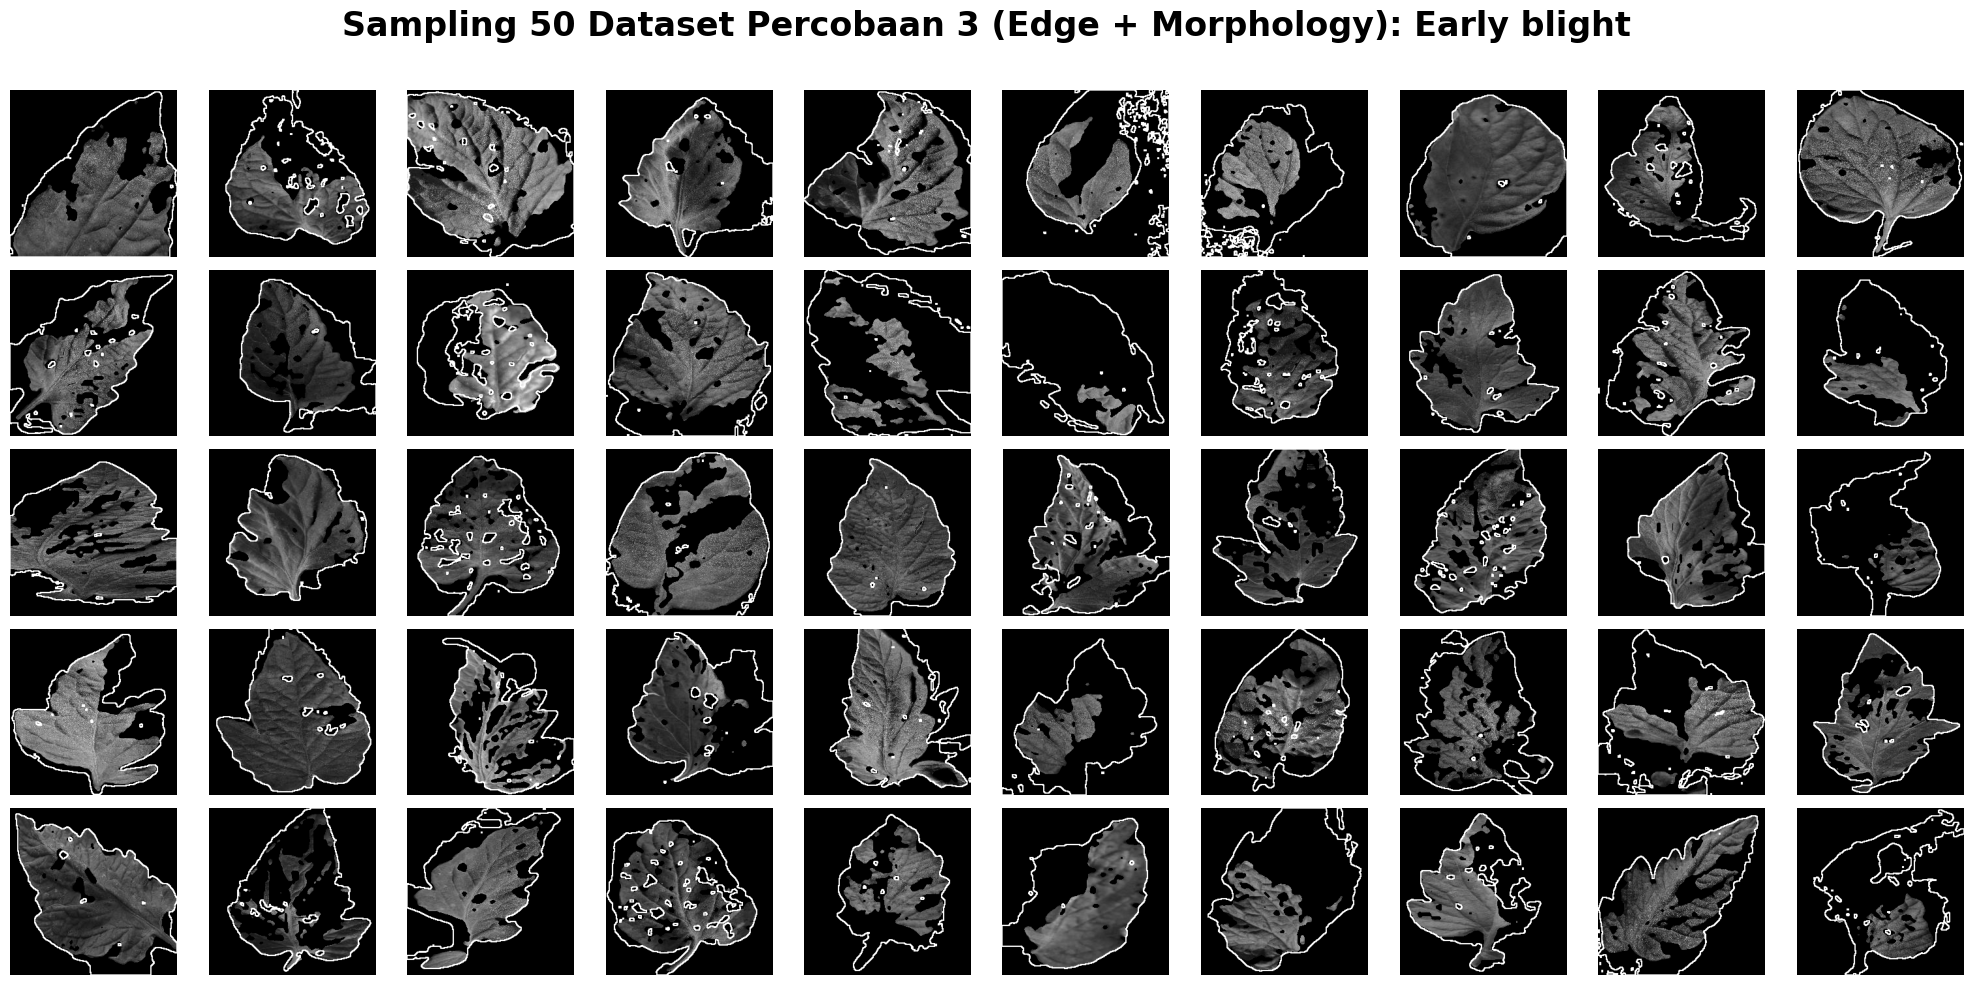

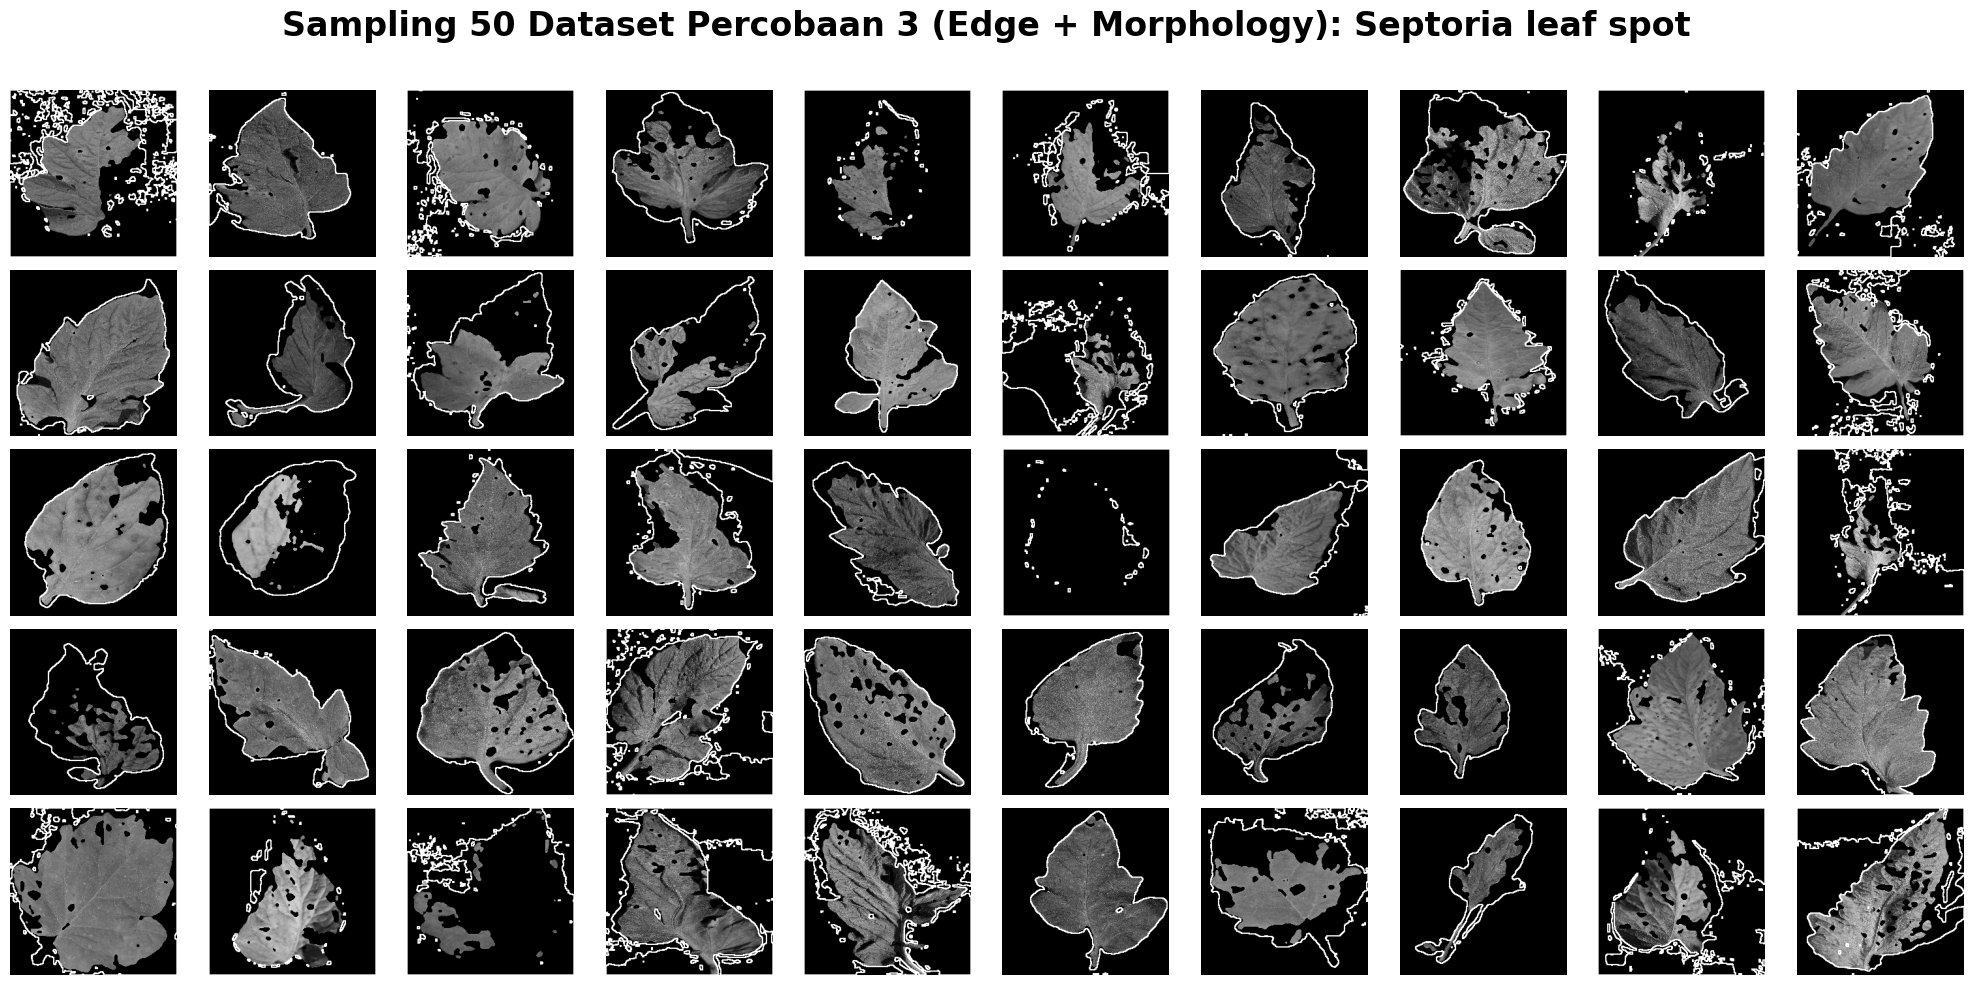

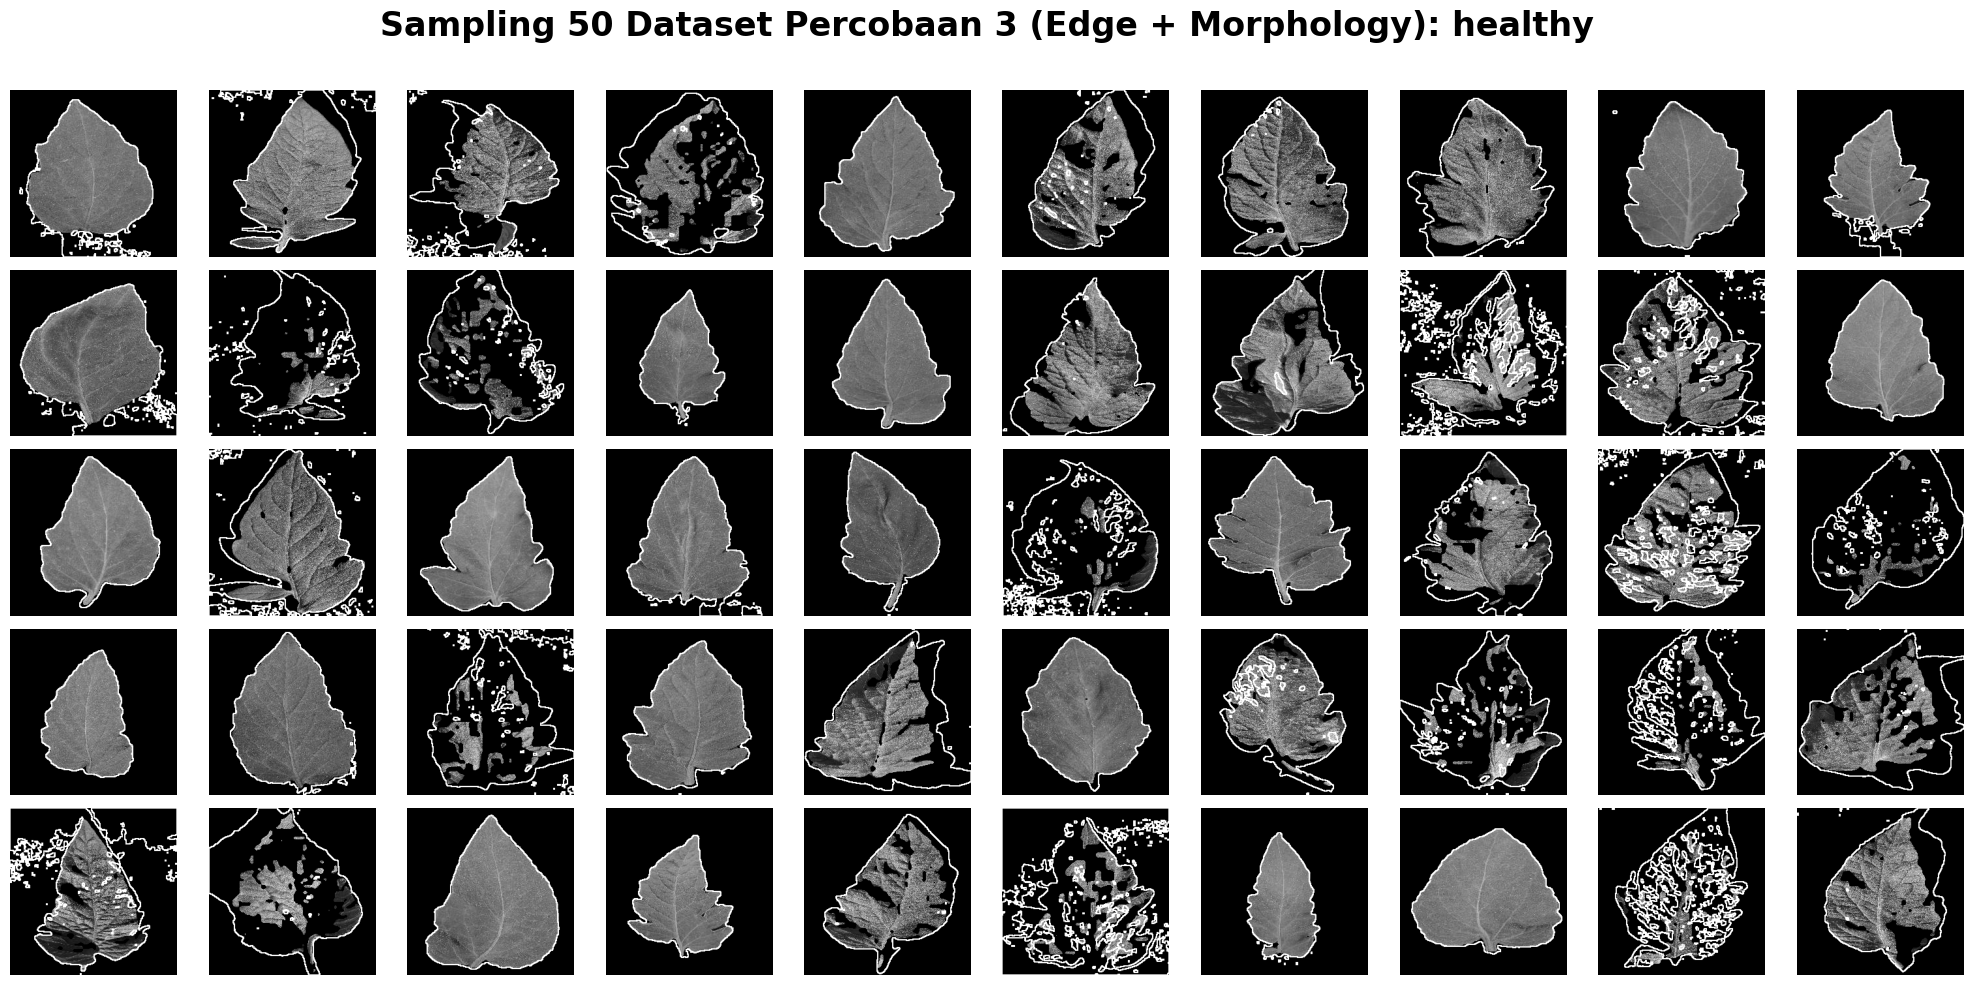

In [6]:
for nama_kelas in target_classes:
    indeks_kelas = [i for i in range(len(labels)) if labels[i] == nama_kelas]

    fig, axes = plt.subplots(5, 10, figsize=(20, 10))
    judul_bersih = nama_kelas.replace("Tomato___", "").replace("_", " ")

    fig.suptitle(
        f"Sampling 50 Dataset Percobaan 3 (Edge + Morphology): {judul_bersih}",
        fontsize=24,
        fontweight='bold'
    )

    for i, ax in enumerate(axes.flat):
        if i < len(indeks_kelas):
            img_show = data_p3[indeks_kelas[i]]
            ax.imshow(img_show, cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

Kode di atas digunakan untuk memvisualisasikan hasil preprocessing yang sudah disimpan pada `data_p3`, sebanyak 50 sampel per kelas. Dilakukan perulangan terhadap setiap `nama_kelas` pada `target_classes`, lalu dicari seluruh indeks citra yang labelnya cocok dengan `nama_kelas` tersebut, namun kali ini menggunakan list comprehension (`[i for i in range(len(labels)) if labels[i] == nama_kelas]`) sebagai versi yang lebih ringkas dibandingkan loop manual dengan `if` dan `append`.

Selanjutnya dibuat grid visualisasi berukuran 5 baris × 10 kolom menggunakan `plt.subplots`, dengan judul yang dibersihkan dari prefix `"Tomato___"` dan underscore diganti spasi, lalu dijadikan judul utama grid dengan format `"Sampling 50 Dataset Percobaan 3 (Edge + Morphology): {judul_bersih}"`.

Pada bagian loop tampilan, setiap slot axes diisi dengan citra dari `data_p3` sesuai indeksnya, selama indeksnya masih tersedia. Slot yang tidak terisi disembunyikan sumbunya dengan `ax.axis('off')` agar tampilan tetap rapi. Terakhir, `plt.tight_layout()` dan `plt.subplots_adjust(top=0.9)` digunakan untuk merapikan tata letak sebelum ditampilkan dengan `plt.show()`.

Dari hasil visualisasinya, terlihat bahwa citra hasil preprocessing pada p3 ini secara visual cukup berbeda dengan pendekatan yang lebih sederhana. Pada banyak sampel, garis outline putih tipis terlihat jelas mengikuti bentuk tepi daun, sesuai dengan tujuan tahap morphological gradient. Namun terlihat juga banyak area hitam (lubang) di bagian dalam beberapa daun, terutama pada kelas Early blight dan Septoria leaf spot, yang merupakan efek dari proses penghapusan area non-hijau (bercak penyakit) pada Tahap B. Pada beberapa sampel (misalnya kolom ke-3 dan ke-5 baris pertama kelas Early blight, serta kolom ke-6 baris ketiga kelas Septoria leaf spot), outline yang terdeteksi juga ikut menangkap noise dari background berupa garis-garis putih kecil yang tidak beraturan di luar bentuk daun, menunjukkan bahwa proses masking saturasi pada Tahap A belum sepenuhnya bersih dari background di beberapa kasus. Pada kelas healthy, area hitam yang muncul relatif lebih sedikit dibandingkan dua kelas penyakit, sejalan dengan logika bahwa daun sehat memiliki lebih banyak area hijau dominan yang tidak terhapus oleh mask pada Tahap B.

In [7]:
print("Memulai proses Ekstraksi Fitur GLCM sesuai template...")

# === 1. DEFINE FUNCTIONS SESUAI TEMPLATE ===
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")
    
    # --- PERBAIKAN DI SINI ---
    # Memaksa tipe data gambar menjadi uint8 agar skimage tidak error
    img_safe = image.astype(np.uint8)
    
    # Mengembalikan matrix glcm dari image 
    glcm = graycomatrix(img_safe, [1], angles, 256, symmetric=True, normed=True)
    return glcm

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

# === 2. EXTRACT MATRIX GLCM UNTUK SETIAP DERAJAT ===
dataPreprocessed = data_p3  # Memetakan hasil preprocessing akhir lu ke template

Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

# === 3. COPAS ARRAY PENAMPUNG DARI TEMPLATE ===
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

# === 4. HITUNG PROPERTI TEKSTUR PER DERAJAT ===
for i in range(len(dataPreprocessed)):
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

for i in range(len(dataPreprocessed)):  
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

# === 5. WRITE THE EXTRACTION'S RESULTS TO CSV ===
dataTable = {
    'Filename': file_name, 
    'Label': labels,
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
}

df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_3.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_3.csv')
print("Ekstraksi Fitur Berhasil Selesai & Disimpan ke CSV!")
hasilEkstrak

Memulai proses Ekstraksi Fitur GLCM sesuai template...
Ekstraksi Fitur Berhasil Selesai & Disimpan ke CSV!


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,0012b9d2-2130-4a06-a834-b1f3af34f57e___RS_Erly...,Tomato___Early_blight,1270.227895,1919.193187,1045.819026,1338.910327,0.576114,0.554806,0.582847,0.567293,...,0.267104,0.261533,0.511258,0.505484,0.516821,0.511403,0.795748,0.683595,0.828309,0.779286
1,0034a551-9512-44e5-ba6c-827f85ecc688___RS_Erly...,Tomato___Early_blight,1955.338266,2645.501223,1755.645021,2753.369181,0.757974,0.729102,0.748299,0.727318,...,0.447554,0.434644,0.667284,0.660044,0.668995,0.659276,0.787835,0.713505,0.809341,0.701824
2,004cbe60-8ff9-4965-92df-e86694d5e9ba___RS_Erly...,Tomato___Early_blight,1843.829580,2604.557093,2134.849755,2916.699685,0.473583,0.453258,0.469037,0.447844,...,0.155038,0.148983,0.397983,0.388446,0.393749,0.385983,0.836200,0.768560,0.811726,0.740823
3,0114f7b3-7f56-4bef-aa47-7a82da142d4b___RS_Erly...,Tomato___Early_blight,1209.372426,1715.511726,1227.587102,1779.110711,0.684217,0.669504,0.684717,0.668129,...,0.393103,0.385426,0.627288,0.621205,0.626979,0.620827,0.850127,0.787785,0.848654,0.779918
4,011aa278-a39e-40b0-b6e4-2e2f835889f0___RS_Erly...,Tomato___Early_blight,1652.182552,2290.145406,1922.192371,2547.567659,0.577872,0.559573,0.571762,0.553027,...,0.258500,0.250433,0.512300,0.503660,0.508429,0.500433,0.822846,0.754868,0.795716,0.727314
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,ff354b62-5981-43d1-8cfe-ac58bc20ca20___GH_HL L...,Tomato___healthy,812.394975,1495.046674,1107.934283,1245.722230,0.585446,0.559353,0.575478,0.565025,...,0.249114,0.246219,0.500902,0.494606,0.499113,0.496205,0.922884,0.858170,0.894830,0.881822
2996,ff774aec-2504-4d11-8a61-2fd74c689a6f___RS_HL 9...,Tomato___healthy,3380.394210,5059.231665,3628.858686,5140.578777,0.881900,0.854032,0.877870,0.853135,...,0.622273,0.600911,0.790482,0.775800,0.788843,0.775185,0.772386,0.659404,0.755073,0.653927
2997,ff8b36d5-feaf-4d2d-8126-18670a312657___RS_HL 0...,Tomato___healthy,1885.433333,2786.652703,1956.691759,2352.749373,0.705916,0.689126,0.705845,0.697278,...,0.445708,0.437460,0.666659,0.657298,0.667613,0.661408,0.829530,0.748027,0.822629,0.787262
2998,ffb39943-eabb-42cf-ad09-b17019e46d66___RS_HL 9...,Tomato___healthy,2696.163894,3820.698870,2732.761979,3761.354018,0.603729,0.582261,0.604304,0.583648,...,0.271542,0.260784,0.519790,0.509659,0.521097,0.510670,0.814008,0.735942,0.811101,0.740035


Kode di atas digunakan untuk melakukan ekstraksi fitur tekstur dari seluruh citra hasil preprocessing pada p3 (gabungan outline morfologi + area daun sehat) menggunakan metode **GLCM (Gray-Level Co-occurrence Matrix)**, lalu menyimpan hasilnya ke dalam file CSV. Proses ini dibagi menjadi 5 bagian utama sesuai dengan komentar yang ada pada kode.

Bagian pertama mendefinisikan kumpulan fungsi yang dibutuhkan. Fungsi `glcm` digunakan untuk menghitung matriks GLCM dari sebuah citra pada sudut tertentu. Sudut yang diterima berupa 0, 45, 90, atau 135 derajat, yang kemudian dikonversi ke radian (`np.pi/4`, `np.pi/2`, `3*np.pi/4`) karena fungsi `graycomatrix` dari skimage membutuhkan input sudut dalam radian. Jika sudut yang diberikan tidak termasuk salah satu dari keempat pilihan tersebut, fungsi akan menghasilkan error melalui `raise ValueError`. Sebelum dihitung, citra dipastikan dulu tipe datanya `uint8` agar tidak terjadi error pada `graycomatrix`. Matriks GLCM dihitung dengan jarak piksel 1 (`[1]`), 256 level keabuan, serta parameter `symmetric=True` dan `normed=True`. Setelah fungsi `glcm` didefinisikan, dibuat pula tujuh fungsi turunan yang masing-masing mengambil satu properti tekstur dari matriks GLCM menggunakan `graycoprops`, yaitu `correlation`, `dissimilarity`, `homogenity`, `contrast`, `ASM`, dan `energy`. Sementara fungsi `entropyGlcm` menghitung nilai entropi dari matriks GLCM menggunakan `entropy` dari scipy, dengan matriks yang diratakan dulu menggunakan `.ravel()` sebelum dihitung.

Bagian kedua melakukan ekstraksi matriks GLCM untuk setiap citra pada `dataPreprocessed`, yang di sini diarahkan ke `data_p3`. Untuk setiap citra, dihitung 4 matriks GLCM sekaligus, masing-masing untuk sudut 0, 45, 90, dan 135 derajat, lalu disimpan ke list `Derajat0`, `Derajat45`, `Derajat90`, dan `Derajat135`. Bagian ketiga menyiapkan 28 list kosong sebagai penampung, yaitu 7 properti tekstur dikali 4 sudut. Bagian keempat menghitung seluruh properti tekstur tersebut untuk setiap citra, dengan masing-masing properti dihitung dalam loop tersendiri (total 7 loop berurutan). Setiap loop memanggil fungsi properti yang sesuai terhadap matriks GLCM pada keempat sudut, lalu hasilnya ditambahkan ke list penampung masing-masing.

Bagian kelima menyusun seluruh hasil ekstraksi ke dalam satu dictionary `dataTable`, yang mencakup nama file, label kelas, dan 28 kolom fitur tekstur. Dictionary ini dikonversi menjadi `DataFrame` menggunakan pandas, lalu disimpan ke file `hasil_ekstraksi_3.csv` tanpa menyertakan index. File CSV tersebut langsung dibaca kembali ke variabel `hasilEkstrak` untuk ditampilkan sebagai konfirmasi bahwa proses ekstraksi berhasil.

Dari hasil tampilannya, terlihat tabel berisi 3000 baris dan 30 kolom, dengan kolom `Filename`, `Label`, serta kolom-kolom numerik untuk setiap fitur tekstur GLCM pada 4 sudut. Dibandingkan hasil ekstraksi pada notebook-notebook sebelumnya, nilai Contrast pada notebook ini terlihat jauh lebih besar dan bervariasi (berkisar dari ratusan hingga ribuan, misalnya 1955.34 hingga 2753.37 pada baris kedua), kemungkinan karena adanya penjumlahan piksel grayscale dengan hasil morphological gradient pada tahap preprocessing yang menambah variasi intensitas piksel secara signifikan. Nilai Correlation tetap berada pada rentang tinggi (sekitar 0.65 hingga 0.85), menunjukkan piksel-piksel yang bertetangga pada citra hasil kombinasi ini masih memiliki korelasi intensitas yang cukup kuat, meskipun sedikit lebih rendah dibandingkan dua notebook sebelumnya.

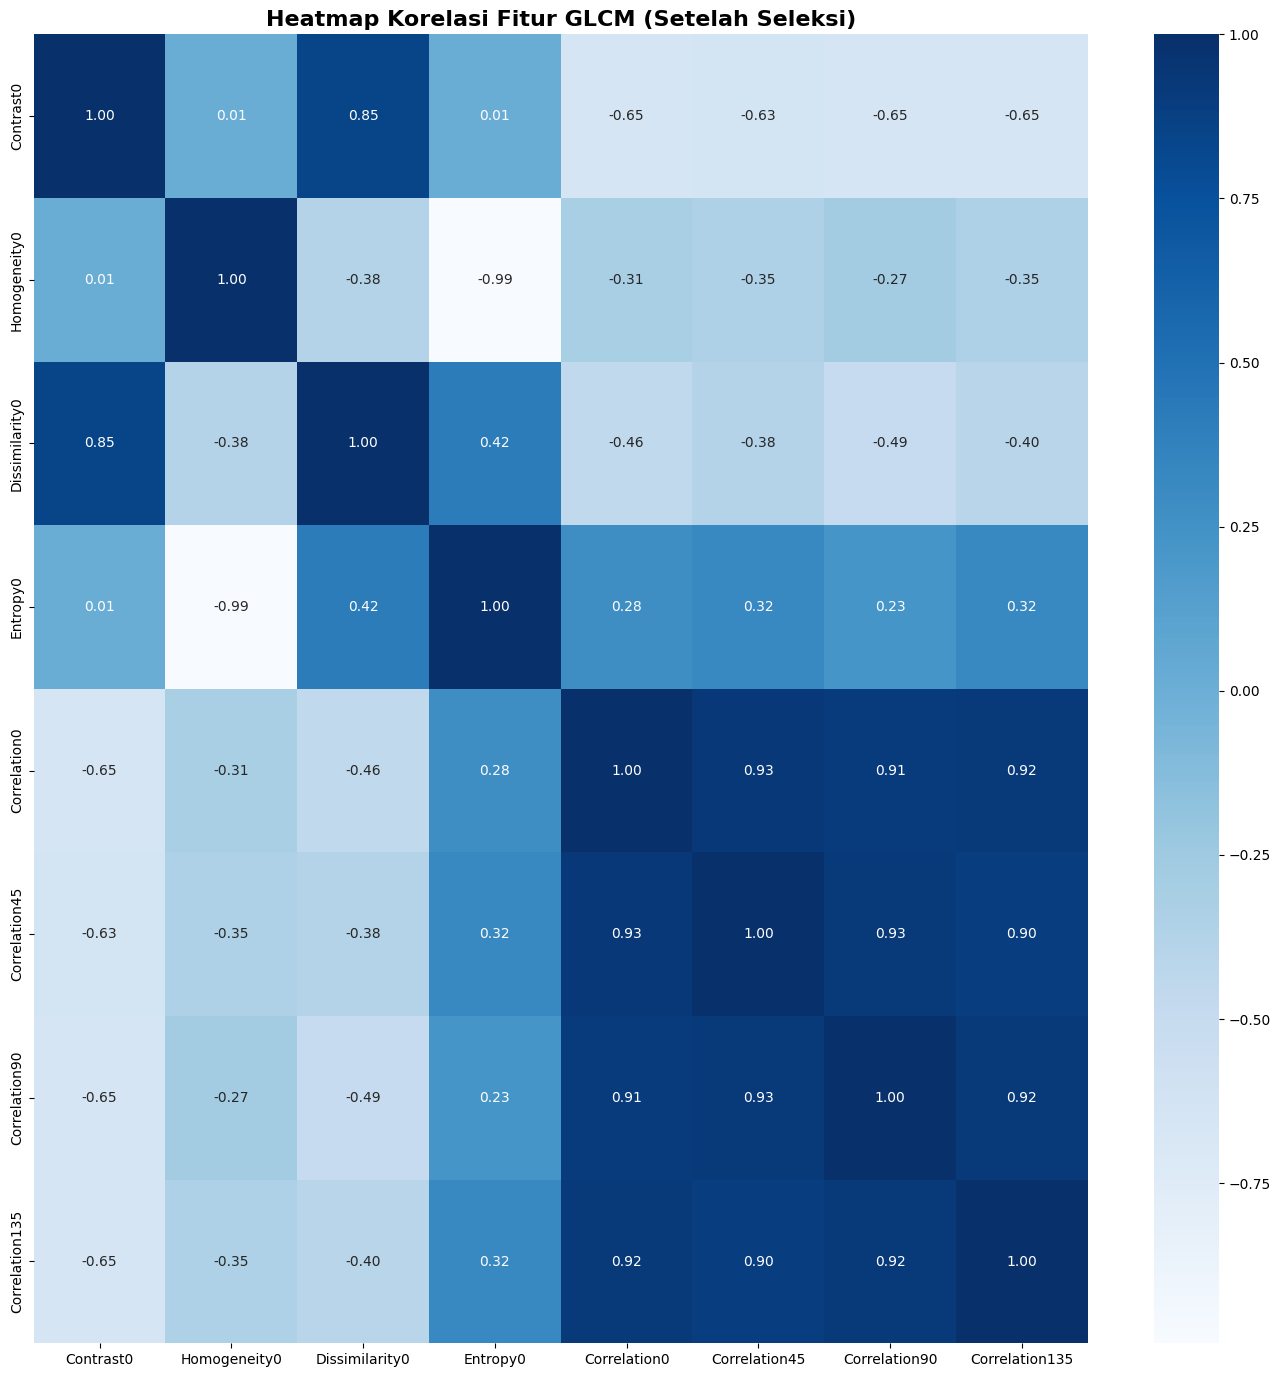

In [8]:
# Menghitung korelasi
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari 0.95 dengan label
threshold = 0.95 # atur threshold ini untuk menentukan seberapa besar korelasi yang ingin disaring
selectionFeature = []
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
x_new
y = hasilEkstrak['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Heatmap Korelasi Fitur GLCM (Setelah Seleksi)', fontsize=16, fontweight='bold')
plt.show()

Kode di atas digunakan untuk melakukan seleksi fitur berdasarkan korelasi antar fitur, dengan tujuan menghapus fitur-fitur yang saling redundan, lalu memvisualisasikan korelasi fitur yang tersisa dalam bentuk heatmap.

Langkah pertama adalah menghitung matriks korelasi antar seluruh fitur numerik menggunakan `hasilEkstrak.drop(columns=['Label','Filename']).corr()`. Kolom `Label` dan `Filename` dihapus terlebih dahulu karena keduanya bukan data numerik, sehingga korelasi hanya dihitung antara 28 kolom fitur tekstur GLCM. Hasilnya disimpan ke variabel `correlation`, berupa matriks korelasi berukuran 28×28.

Selanjutnya ditentukan `threshold` sebesar 0.95, yang berarti dua fitur akan dianggap terlalu mirip jika nilai korelasi absolutnya mencapai 0.95 atau lebih. Sebuah array boolean bernama `columns` disiapkan dengan nilai awal semuanya `True`, berukuran sebanyak jumlah fitur. Logika seleksi fitur dilakukan dengan dua loop bersarang (`for i` dan `for j`). Untuk setiap pasangan kolom `i` dan `j` (dengan `j` selalu lebih besar dari `i`), dicek apakah nilai korelasi antara kolom `i` dan `j` lebih besar atau sama dengan threshold. Jika ya, maka kolom `j` ditandai menjadi `False`, artinya kolom tersebut akan dibuang. Dengan logika ini, jika ada dua fitur yang berkorelasi sangat tinggi, hanya fitur dengan indeks yang lebih kecil yang dipertahankan.

Setelah proses seleksi selesai, kolom-kolom yang masih bernilai `True` diambil sebagai daftar fitur terpilih (`select`), kemudian digunakan untuk membentuk `x_new`, yaitu subset dari `hasilEkstrak` yang hanya berisi fitur-fitur terpilih. Variabel `y` dibuat untuk menampung label kelas dari `hasilEkstrak['Label']`. Bagian terakhir kode ini membuat visualisasi heatmap dari matriks korelasi antar fitur yang sudah terseleksi, menggunakan `seaborn.heatmap` dengan colormap biru dan nilai korelasi ditampilkan dengan 2 angka desimal.

Dari hasil visualisasinya, terlihat bahwa proses seleksi fitur pada notebook ini menyisakan 8 fitur dari 28 fitur awal, yaitu `Contrast0`, `Homogeneity0`, `Dissimilarity0`, `Entropy0`, `Correlation0`, `Correlation45`, `Correlation90`, dan `Correlation135`. Jumlah fitur yang tersisa ini lebih banyak dibandingkan notebook-notebook sebelumnya, menunjukkan bahwa fitur-fitur pada p3 cenderung lebih bervariasi antar sudut (tidak terlalu redundan satu sama lain di atas threshold 0.95). Namun pada heatmap fitur yang tersisa, masih terlihat banyak korelasi yang sangat kuat, misalnya antara `Homogeneity0` dan `Entropy0` yang mencapai -0.99 (hampir sempurna), antara `Contrast0` dan `Dissimilarity0` yang mencapai 0.85, serta antar keempat fitur Correlation pada sudut berbeda yang seluruhnya berkorelasi di atas 0.90 satu sama lain. Hal ini menunjukkan bahwa meskipun lolos dari threshold 0.95 karena kebetulan urutan kolom dan posisi sudut yang dibandingkan, redundansi antar fitur pada notebook ini sebenarnya masih cukup tinggi, terutama pada kelompok fitur Correlation di keempat sudut yang hampir identik satu sama lain.

In [9]:
# === 1. SPLITTING DATA ===
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.2 = 20% data untuk testing (train/test 80/20)
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

# === 2. FEATURE NORMALIZATION ===
# normalisasi mean std
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

(2400, 8)
(600, 8)


Kode di atas digunakan untuk membagi dataset menjadi data latih dan data uji, kemudian menormalisasi nilai fitur agar berada pada skala yang seragam sebelum digunakan untuk training model.

Bagian pertama melakukan splitting data menggunakan `train_test_split` dari `x_new` (fitur hasil seleksi) dan `y` (label kelas). Parameter `test_size=0.2` berarti 20% dari total data dialokasikan untuk data uji, sementara 80% sisanya untuk data latih. Parameter `random_state=42` digunakan agar proses pembagian data bersifat reproducible. Hasil dari fungsi ini langsung ditampung ke empat variabel sekaligus, yaitu `X_train`, `X_test`, `y_train`, dan `y_test`. Bentuk (shape) dari `X_train` dan `X_test` kemudian ditampilkan menggunakan `print` untuk memastikan ukuran data sudah sesuai.

Bagian kedua melakukan normalisasi fitur menggunakan metode standarisasi (z-score), yaitu mengurangkan setiap nilai fitur dengan rata-rata (`mean`) lalu membaginya dengan standar deviasi (`std`). Baik `X_test` maupun `X_train` dinormalisasi menggunakan nilai mean dan std yang dihitung dari `X_train` saja, bukan dari `X_test`, agar tidak terjadi kebocoran informasi (data leakage) dari data uji ke proses training.

Dari hasil output yang ditampilkan, terlihat bahwa `X_train` memiliki ukuran (2400, 8) dan `X_test` memiliki ukuran (600, 8). Angka 2400 dan 600 menunjukkan jumlah baris data latih dan data uji secara berurutan, yang berasal dari total 3000 data dengan pembagian 80:20. Sementara angka 8 menunjukkan jumlah fitur yang digunakan, sesuai dengan jumlah fitur yang tersisa setelah proses seleksi pada cell sebelumnya (`Contrast0`, `Homogeneity0`, `Dissimilarity0`, `Entropy0`, `Correlation0`, `Correlation45`, `Correlation90`, `Correlation135`).

In [10]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

Kode di atas digunakan untuk mendefinisikan fungsi evaluasi model serta menyiapkan tiga algoritma klasifikasi yang akan dilatih dan dibandingkan performanya.

Fungsi `generateClassificationReport` dibuat untuk menyederhanakan proses evaluasi, agar tidak perlu menulis ulang kode evaluasi yang sama setiap kali mengevaluasi model. Fungsi ini menerima dua parameter, yaitu `y_true` (label sebenarnya) dan `y_pred` (label hasil prediksi model), lalu menampilkan tiga jenis informasi evaluasi sekaligus, yaitu `classification_report` (precision, recall, f1-score, support per kelas), `confusion_matrix` (tabel perbandingan label sebenarnya dengan hasil prediksi), dan `accuracy_score` (persentase prediksi yang benar secara keseluruhan).

Bagian kedua mendefinisikan tiga model klasifikasi yang akan digunakan. Model pertama adalah `RandomForestClassifier` dengan konfigurasi yang sudah di-tuning. Parameter `n_estimators=200` berarti hutan ini dibangun dari 200 pohon keputusan. Parameter `max_depth=15` membatasi kedalaman maksimum setiap pohon hingga 15 level, untuk mencegah pohon tumbuh terlalu dalam dan menghafal data latih secara berlebihan. Parameter `min_samples_split=5` menetapkan bahwa sebuah node hanya akan dipecah lebih lanjut jika memiliki minimal 5 sampel data, sementara `min_samples_leaf=2` menetapkan bahwa setiap node daun minimal harus berisi 2 sampel data. Parameter `max_features='sqrt'` berarti setiap kali melakukan split, algoritma hanya mempertimbangkan sejumlah akar kuadrat dari total fitur secara acak, bukan seluruh fitur, untuk menambah variasi antar pohon dalam ensemble.

Model kedua adalah `SVC` dengan kernel `'rbf'` (Radial Basis Function), kernel non-linear yang umum digunakan untuk menangani data yang tidak dapat dipisahkan secara linear. Model ketiga adalah `KNeighborsClassifier` dengan `n_neighbors=5`, yang berarti setiap data baru akan diklasifikasikan berdasarkan mayoritas kelas dari 5 data tetangga terdekatnya. Parameter `random_state=42` pada `RandomForestClassifier` dan `SVC` digunakan untuk memastikan hasil yang konsisten setiap kali model dijalankan ulang.

In [11]:
# === 1. TRAIN & EVALUATE RANDOM FOREST ===
print("==================================================")
print("              RANDOM FOREST CLASSIFIER            ")
print("==================================================")
rf.fit(X_train, y_train)

print("------Training Set------")
y_pred_train_rf = rf.predict(X_train)
generateClassificationReport(y_train, y_pred_train_rf)

print("\n------Testing Set------")
y_pred_test_rf = rf.predict(X_test)
generateClassificationReport(y_test, y_pred_test_rf)

              RANDOM FOREST CLASSIFIER            
------Training Set------
                             precision    recall  f1-score   support

      Tomato___Early_blight       0.98      0.99      0.98       783
Tomato___Septoria_leaf_spot       0.98      0.98      0.98       803
           Tomato___healthy       0.99      0.99      0.99       814

                   accuracy                           0.98      2400
                  macro avg       0.98      0.98      0.98      2400
               weighted avg       0.98      0.98      0.98      2400

[[774   6   3]
 [ 15 783   5]
 [  4   6 804]]
Accuracy: 0.98375

------Testing Set------
                             precision    recall  f1-score   support

      Tomato___Early_blight       0.76      0.82      0.79       217
Tomato___Septoria_leaf_spot       0.75      0.65      0.70       197
           Tomato___healthy       0.87      0.91      0.89       186

                   accuracy                           0.79       600
  

Kode di atas digunakan untuk melatih model `RandomForestClassifier` (dengan konfigurasi parameter yang sudah di-tuning pada cell sebelumnya), lalu mengevaluasi performanya baik pada data latih maupun data uji.

Pertama, dicetak judul pemisah berupa garis `"="` sebanyak 50 karakter beserta teks `"RANDOM FOREST CLASSIFIER"` di tengahnya. Model `rf` kemudian dilatih menggunakan `rf.fit(X_train, y_train)`, yaitu proses di mana model membangun 200 pohon keputusan berdasarkan pola dari data latih beserta labelnya.

Setelah model dilatih, dilakukan evaluasi pada data latih (training set). Model digunakan untuk memprediksi label dari `X_train` itu sendiri melalui `rf.predict(X_train)`, hasilnya disimpan ke `y_pred_train_rf`. Prediksi ini kemudian dibandingkan dengan label sebenarnya (`y_train`) menggunakan fungsi `generateClassificationReport` yang sudah didefinisikan sebelumnya, untuk menampilkan precision, recall, f1-score, confusion matrix, dan akurasi.

Langkah yang sama diulang untuk data uji (testing set). Model memprediksi label dari `X_test` yang belum pernah dilihat sebelumnya selama training, hasilnya disimpan ke `y_pred_test_rf`, lalu dibandingkan dengan `y_test` menggunakan fungsi evaluasi yang sama.

Dari hasil outputnya, terlihat bahwa pada data latih, model Random Forest mencapai akurasi sebesar 98.38% (0.98), dengan precision, recall, dan f1-score yang sangat tinggi untuk ketiga kelas (berkisar 0.98 hingga 0.99). Namun pada data uji, akurasi turun cukup jauh menjadi 79.17% (0.79). Penurunan performa antara data latih dan data uji ini cukup besar, sekitar 19 poin persentase, mengindikasikan adanya overfitting yang cukup signifikan, bahkan lebih besar dibandingkan gap yang terlihat pada notebook-notebook sebelumnya, meskipun parameter Random Forest yang digunakan sudah sama-sama di-tuning. Hal ini menunjukkan bahwa kompleksitas fitur hasil preprocessing pada p3 (yang menggabungkan outline morfologi dan area daun sehat) kemungkinan menghasilkan pola pada data latih yang lebih mudah dihafal oleh model namun kurang mampu digeneralisasi ke data baru.

In [12]:
# === 2. TRAIN & EVALUATE SVM ===
print("\n==================================================")
print("                   SVM CLASSIFIER                 ")
print("==================================================")
svm.fit(X_train, y_train)

print("------Training Set------")
y_pred_train_svm = svm.predict(X_train)
generateClassificationReport(y_train, y_pred_train_svm)

print("\n------Testing Set------")
y_pred_test_svm = svm.predict(X_test)
generateClassificationReport(y_test, y_pred_test_svm)


                   SVM CLASSIFIER                 
------Training Set------
                             precision    recall  f1-score   support

      Tomato___Early_blight       0.78      0.86      0.82       783
Tomato___Septoria_leaf_spot       0.82      0.71      0.76       803
           Tomato___healthy       0.89      0.93      0.91       814

                   accuracy                           0.83      2400
                  macro avg       0.83      0.83      0.83      2400
               weighted avg       0.83      0.83      0.83      2400

[[672  76  35]
 [181 567  55]
 [ 11  49 754]]
Accuracy: 0.8304166666666667

------Testing Set------
                             precision    recall  f1-score   support

      Tomato___Early_blight       0.78      0.87      0.83       217
Tomato___Septoria_leaf_spot       0.80      0.65      0.72       197
           Tomato___healthy       0.87      0.93      0.90       186

                   accuracy                           0.82 

Kode di atas digunakan untuk melatih model `SVC` (Support Vector Classifier) yang sudah didefinisikan sebelumnya, lalu mengevaluasi performanya baik pada data latih maupun data uji.

Pertama, dicetak judul pemisah berupa garis `"="` sebanyak 50 karakter beserta teks `"SVM CLASSIFIER"` di tengahnya. Model `svm` kemudian dilatih menggunakan `svm.fit(X_train, y_train)`, yaitu proses di mana model mencari hyperplane terbaik untuk memisahkan ketiga kelas berdasarkan fitur-fitur yang ada, dengan bantuan kernel `'rbf'` untuk menangani pola yang tidak dapat dipisahkan secara linear.

Setelah model dilatih, dilakukan evaluasi pada data latih (training set). Model digunakan untuk memprediksi label dari `X_train` itu sendiri melalui `svm.predict(X_train)`, hasilnya disimpan ke `y_pred_train_svm`. Prediksi ini kemudian dibandingkan dengan label sebenarnya (`y_train`) menggunakan fungsi `generateClassificationReport`, untuk menampilkan precision, recall, f1-score, confusion matrix, dan akurasi.

Langkah yang sama diulang untuk data uji (testing set). Model memprediksi label dari `X_test` yang belum pernah dilihat sebelumnya selama training, hasilnya disimpan ke `y_pred_test_svm`, lalu dibandingkan dengan `y_test` menggunakan fungsi evaluasi yang sama.

Dari hasil outputnya, terlihat bahwa pada data latih, model SVM mencapai akurasi sebesar 83.04% (0.83), dengan precision tertinggi pada kelas `Tomato_healthy` (0.89) dan terendah pada kelas `Early_blight` (0.78). Sementara pada data uji, akurasi sedikit menurun menjadi 81.67% (0.82). Selisih antara akurasi data latih dan data uji ini relatif kecil, hanya sekitar 1-2 poin persentase, menunjukkan model SVM pada konfigurasi ini memiliki kemampuan generalisasi yang cukup baik dan tidak mengalami overfitting yang signifikan, jauh lebih stabil dibandingkan Random Forest pada notebook ini.

In [13]:
# === 3. TRAIN & EVALUATE KNN ===
print("\n==================================================")
print("                   KNN CLASSIFIER                 ")
print("==================================================")
knn.fit(X_train, y_train)

print("------Training Set------")
y_pred_train_knn = knn.predict(X_train)
generateClassificationReport(y_train, y_pred_train_knn)

print("\n------Testing Set------")
y_pred_test_knn = knn.predict(X_test)
generateClassificationReport(y_test, y_pred_test_knn)


                   KNN CLASSIFIER                 
------Training Set------
                             precision    recall  f1-score   support

      Tomato___Early_blight       0.81      0.90      0.85       783
Tomato___Septoria_leaf_spot       0.87      0.77      0.82       803
           Tomato___healthy       0.92      0.93      0.92       814

                   accuracy                           0.87      2400
                  macro avg       0.87      0.87      0.86      2400
               weighted avg       0.87      0.87      0.87      2400

[[702  64  17]
 [133 622  48]
 [ 33  27 754]]
Accuracy: 0.8658333333333333

------Testing Set------
                             precision    recall  f1-score   support

      Tomato___Early_blight       0.75      0.82      0.79       217
Tomato___Septoria_leaf_spot       0.75      0.64      0.69       197
           Tomato___healthy       0.87      0.91      0.89       186

                   accuracy                           0.79 

Kode di atas digunakan untuk melatih model `KNeighborsClassifier` yang sudah didefinisikan sebelumnya, lalu mengevaluasi performanya baik pada data latih maupun data uji.

Pertama, dicetak judul pemisah berupa garis `"="` sebanyak 50 karakter beserta teks `"KNN CLASSIFIER"` di tengahnya. Model `knn` kemudian dilatih menggunakan `knn.fit(X_train, y_train)`. Perlu dicatat bahwa proses "training" pada KNN sebenarnya berbeda dengan Random Forest maupun SVM, karena KNN tidak benar-benar membangun model pembelajaran dari data, melainkan hanya menyimpan seluruh data latih ke dalam memori untuk digunakan saat proses prediksi nanti (dikenal sebagai *lazy learning*).

Setelah itu, dilakukan evaluasi pada data latih (training set). Model digunakan untuk memprediksi label dari `X_train` melalui `knn.predict(X_train)`, hasilnya disimpan ke `y_pred_train_knn`. Prediksi ini kemudian dibandingkan dengan label sebenarnya (`y_train`) menggunakan fungsi `generateClassificationReport`, untuk menampilkan precision, recall, f1-score, confusion matrix, dan akurasi.

Langkah yang sama diulang untuk data uji (testing set). Model memprediksi label dari `X_test` melalui `knn.predict(X_test)`, hasilnya disimpan ke `y_pred_test_knn`, lalu dibandingkan dengan `y_test` menggunakan fungsi evaluasi yang sama.

Dari hasil outputnya, terlihat bahwa pada data latih, model KNN mencapai akurasi sebesar 86.58% (0.87), dengan precision tertinggi pada kelas `Tomato_healthy` (0.92) dan terendah pada kelas `Early_blight` (0.81). Sementara pada data uji, akurasi turun cukup signifikan menjadi 79.17% (0.79). Selisih antara akurasi data latih dan data uji ini sekitar 7 poin persentase, lebih besar dibandingkan SVM pada notebook ini, namun masih jauh lebih kecil dibandingkan gap pada Random Forest sebelumnya. Hal ini menunjukkan bahwa model KNN dengan `n_neighbors=5` pada notebook ini mengalami sedikit indikasi overfitting, meskipun tidak separah Random Forest.

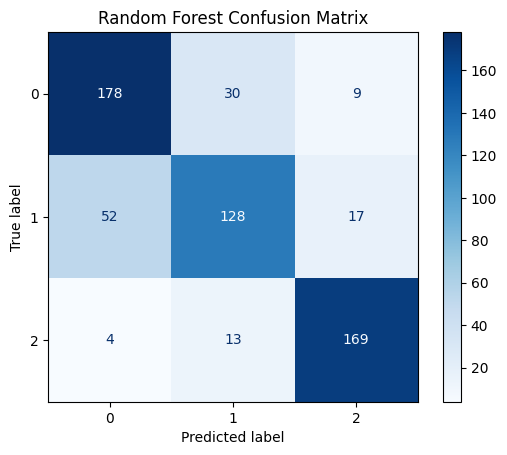

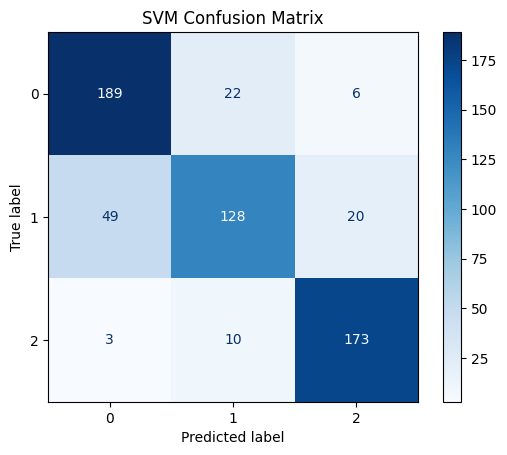

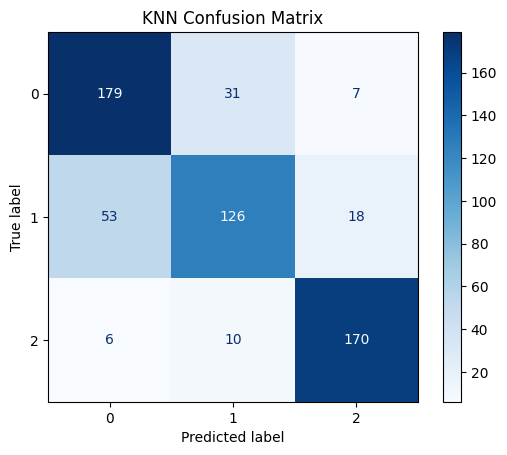

In [14]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")

Kode di atas digunakan untuk membuat fungsi visualisasi confusion matrix, lalu memanggilnya untuk ketiga model (Random Forest, SVM, dan KNN) pada data uji, sehingga performa ketiganya bisa dibandingkan secara visual.

Fungsi `plot_confusion_matrix` dibuat untuk menyederhanakan proses visualisasi, agar tidak perlu menulis ulang kode yang sama untuk setiap model. Fungsi ini menerima tiga parameter, yaitu `y_true` (label sebenarnya), `y_pred` (label hasil prediksi), dan `title` (judul plot). Di dalamnya, pertama dihitung confusion matrix menggunakan `confusion_matrix(y_true, y_pred)`. Matriks ini kemudian dibungkus dengan `ConfusionMatrixDisplay` agar dapat ditampilkan secara visual, lalu di-plot menggunakan `disp.plot(cmap=plt.cm.Blues)` dengan skema warna biru. Judul plot diatur sesuai parameter `title` yang diberikan, sebelum akhirnya ditampilkan dengan `plt.show()`.

Setelah fungsi didefinisikan, dipanggil tiga kali secara berurutan untuk ketiga model. Untuk setiap pemanggilan, model memprediksi ulang label dari `X_test`, lalu hasil prediksi tersebut dibandingkan dengan `y_test` yang sebenarnya melalui fungsi `plot_confusion_matrix`, masing-masing dengan judul yang sesuai nama modelnya.

Dari hasil visualisasinya, ketiga confusion matrix menunjukkan pola kesalahan yang relatif konsisten. Pada confusion matrix Random Forest, kesalahan klasifikasi paling banyak terjadi pada kelas 1 (Septoria leaf spot), di mana 56 data justru terprediksi sebagai kelas 0 (Early blight), jumlah kesalahan tertinggi di antara ketiga model untuk pasangan kelas ini. Pada confusion matrix SVM, performa terlihat paling baik secara keseluruhan, dengan 189 data benar pada kelas 0 (tertinggi di antara ketiga model) dan kesalahan yang relatif lebih sedikit pada kelas 1 dan 2 dibandingkan Random Forest. Pada confusion matrix KNN, hasilnya berada di antara kedua model sebelumnya, dengan 179 data benar pada kelas 0 dan 126 data benar pada kelas 1.

Secara umum, ketiga model pada notebook ini menunjukkan kecenderungan yang sama, yaitu kesalahan klasifikasi paling banyak terjadi antara kelas 0 (Early blight) dan kelas 1 (Septoria leaf spot), sementara kelas 2 (healthy) relatif lebih jarang tertukar dengan kedua kelas penyakit tersebut. Dibandingkan dua notebook sebelumnya, jumlah kesalahan pada pasangan kelas 0 dan 1 di notebook ini cenderung lebih tinggi, terutama pada Random Forest, sejalan dengan akurasi testing yang juga lebih rendah secara keseluruhan pada notebook ini.